# Expected Points Models by Position

Linear regression models predicting next gameweek's points from:
- Average points per game (season to date)
- Average points per game (last 6 featured games)
- Fixture difficulty (easy/medium/hard)
- Home/Away

Walk-forward validation: GW 28-33 test, GW 1-27+ train (expanding window)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ML
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)

print('Imports successful!')

Imports successful!


## 1. Load Data

In [ ]:
# Load all gameweek CSVs
data_dir = Path('data')
csv_files = sorted(data_dir.glob('player_stats_gw*.csv'))

dfs = [pd.read_csv(f) for f in csv_files]
df = pd.concat(dfs, ignore_index=True)

# Sort by player and gameweek
df = df.sort_values(['player_id', 'gameweek']).reset_index(drop=True)

print(f'Loaded {len(csv_files)} gameweeks')
print(f'Total rows: {len(df):,}')
print(f'Gameweeks: {df["gameweek"].min()}-{df["gameweek"].max()}')
print(f'\nPositions: {df["position"].unique()}')

## 2. Build Rolling Features

For each player at gameweek N:
- `avg_pts_season`: mean points in GW 1..N-1 where player featured (mins > 0)
- `avg_pts_last_6`: mean points in last 6 featured games before GW N

In [ ]:
# Create a featured-games-only view for rolling calculations
df_featured = df[df['minutes_played'] > 0].copy()

# For each player, compute cumulative mean (season avg) — using shift to avoid leakage
df['avg_pts_season'] = (
    df.groupby('player_id')['points']
    .shift(1)  # Exclude current game
    .expanding(min_periods=1)
    .mean()
    .values
)

# For last-6 avg, compute on featured games only, then merge back
# Strategy: for featured games, compute rolling mean of last 6, then merge to all rows
avg_pts_last_6_series = (
    df_featured.groupby('player_id')['points']
    .shift(1)
    .rolling(window=6, min_periods=1)
    .mean()
)

# Add it to df_featured before merging
df_featured['avg_pts_last_6'] = avg_pts_last_6_series.values

# Merge back to main dataframe
df = df.merge(
    df_featured[['player_id', 'gameweek', 'avg_pts_last_6']],
    on=['player_id', 'gameweek'],
    how='left'
)

# For non-featured games, use season avg for last_6 (fallback)
df['avg_pts_last_6'] = df['avg_pts_last_6'].fillna(df['avg_pts_season'])

print(f'\nSample rows with rolling features:')
print(df[['player_id', 'gameweek', 'position', 'points', 'avg_pts_season', 'avg_pts_last_6', 'fixture_difficulty', 'is_home']].head(15))


Sample rows with rolling features:
    player_id  gameweek position  points  avg_pts_season  avg_pts_last_6  \
0        2076        23      MID       0             NaN             NaN   
1        3774         1       GK       0             NaN             NaN   
2        3774         2       GK       0        0.000000        0.000000   
3        3774         3       GK       0        0.000000        0.000000   
4        3774         4       GK       0        0.000000        0.000000   
5        3774         5       GK       0        0.000000        0.000000   
6        3774         6       GK       3        0.000000        0.000000   
7        3774         7       GK       3        0.500000        3.000000   
8        3774         8       GK       2        0.857143        3.000000   
9        3774         9       GK       7        1.000000        2.666667   
10       3774        10       GK       2        1.666667        3.750000   
11       3774        11       GK       1        1.70

## 3. Encode Categorical Features

In [ ]:
# Encode fixture difficulty
difficulty_map = {'easy': 0, 'medium': 1, 'hard': 2}
df['fixture_difficulty_encoded'] = df['fixture_difficulty'].map(difficulty_map).fillna(1)  # Default to medium

# Encode is_home (H=1, A=0)
df['is_home_binary'] = (df['is_home'] == 'H').astype(int)

print('Encoded features:')
print(df[['fixture_difficulty', 'fixture_difficulty_encoded', 'is_home', 'is_home_binary']].head(10))

Encoded features:
  fixture_difficulty  fixture_difficulty_encoded is_home  is_home_binary
0               hard                         2.0       A               0
1             medium                         1.0       A               0
2               easy                         0.0       H               1
3             medium                         1.0       H               1
4               easy                         0.0       A               0
5               hard                         2.0       H               1
6               hard                         2.0       A               0
7               easy                         0.0       H               1
8             medium                         1.0       A               0
9               hard                         2.0       H               1


## 4. Filter to GW 20+ (ensure sufficient history)

In [ ]:
df_train = df[df['gameweek'] >= 20].copy()
df_train = df_train.dropna(subset=['avg_pts_season', 'avg_pts_last_6'])

print(f'Rows with GW >= 20: {len(df_train):,}')
print(f'Gameweeks: {df_train["gameweek"].min()}-{df_train["gameweek"].max()}')
print(f'Positions: {df_train["position"].unique()}')

Rows with GW >= 20: 56,537
Gameweeks: 20-34
Positions: <StringArray>
['GK', 'FWD', 'DEF', 'MID']
Length: 4, dtype: str


## 5. Walk-Forward Validation (GW 28-33)

For each test gameweek, train on all prior data and predict that gameweek

In [ ]:
test_gws = [28, 29, 30, 31, 32, 33]
positions = ['GK', 'DEF', 'MID', 'FWD']

# Storage for results
all_predictions = []
all_actuals = []
model_results = {}

for position in positions:
    print(f'\n=== {position} ===')
    model_results[position] = {'baseline': [], 'full': []}
    
    for test_gw in test_gws:
        # Split: train on all data before test_gw
        train_data = df_train[(df_train['gameweek'] < test_gw) & (df_train['position'] == position)]
        test_data = df_train[(df_train['gameweek'] == test_gw) & (df_train['position'] == position)]
        
        if len(train_data) == 0 or len(test_data) == 0:
            print(f'  GW {test_gw}: Skipped (insufficient data)')
            continue
        
        # Features
        X_train_full = train_data[['avg_pts_season', 'avg_pts_last_6', 'fixture_difficulty_encoded', 'is_home_binary']]
        X_train_base = train_data[['avg_pts_season']]
        y_train = train_data['points']
        
        X_test_full = test_data[['avg_pts_season', 'avg_pts_last_6', 'fixture_difficulty_encoded', 'is_home_binary']]
        X_test_base = test_data[['avg_pts_season']]
        y_test = test_data['points']
        
        # Train baseline (avg_pts_season only)
        model_base = LinearRegression()
        model_base.fit(X_train_base, y_train)
        y_pred_base = model_base.predict(X_test_base)
        mae_base = mean_absolute_error(y_test, y_pred_base)
        mse_base = mean_squared_error(y_test, y_pred_base)
        rmse_base = np.sqrt(mse_base)
        r2_base = r2_score(y_test, y_pred_base)
        
        # Train full model
        model_full = LinearRegression()
        model_full.fit(X_train_full, y_train)
        y_pred_full = model_full.predict(X_test_full)
        mae_full = mean_absolute_error(y_test, y_pred_full)
        mse_full = mean_squared_error(y_test, y_pred_full)
        rmse_full = np.sqrt(mse_full)
        r2_full = r2_score(y_test, y_pred_full)
        
        # Store results
        model_results[position]['baseline'].append({'gw': test_gw, 'mae': mae_base, 'mse': mse_base, 'rmse': rmse_base, 'r2': r2_base})
        model_results[position]['full'].append({'gw': test_gw, 'mae': mae_full, 'mse': mse_full, 'rmse': rmse_full, 'r2': r2_full})
        
        print(f'  GW {test_gw} (train: {len(train_data)}, test: {len(test_data)})')
        print(f'    Baseline - MAE: {mae_base:.3f}, RMSE: {rmse_base:.3f}, R²: {r2_base:.3f}')
        print(f'    Full     - MAE: {mae_full:.3f}, RMSE: {rmse_full:.3f}, R²: {r2_full:.3f}')
        
        # Collect for aggregate metrics
        all_predictions.append(y_pred_full)
        all_actuals.append(y_test.values)

print('\nWalk-forward validation complete!')


=== GK ===
  GW 28 (train: 2623, test: 322)
    Baseline - MAE: 2.357, RMSE: 3.201, R²: 0.001
    Full     - MAE: 1.609, RMSE: 2.465, R²: 0.407
  GW 29 (train: 2945, test: 379)
    Baseline - MAE: 2.210, RMSE: 2.837, R²: -0.001
    Full     - MAE: 1.652, RMSE: 2.443, R²: 0.258
  GW 30 (train: 3324, test: 409)
    Baseline - MAE: 1.915, RMSE: 2.467, R²: 0.017
    Full     - MAE: 1.304, RMSE: 1.938, R²: 0.393
  GW 31 (train: 3733, test: 310)
    Baseline - MAE: 2.216, RMSE: 2.862, R²: 0.026
    Full     - MAE: 1.436, RMSE: 2.136, R²: 0.458
  GW 32 (train: 4043, test: 440)
    Baseline - MAE: 2.026, RMSE: 2.670, R²: 0.021
    Full     - MAE: 1.447, RMSE: 2.222, R²: 0.322
  GW 33 (train: 4483, test: 479)
    Baseline - MAE: 2.256, RMSE: 2.941, R²: 0.007
    Full     - MAE: 1.557, RMSE: 2.345, R²: 0.369

=== DEF ===
  GW 28 (train: 9151, test: 1139)
    Baseline - MAE: 2.672, RMSE: 3.287, R²: 0.016
    Full     - MAE: 2.133, RMSE: 2.763, R²: 0.305
  GW 29 (train: 10290, test: 1318)
    Bas

## 6. Aggregate Results

In [ ]:
# Combine all predictions and actuals
all_preds = np.concatenate(all_predictions)
all_acts = np.concatenate(all_actuals)

# Aggregate metrics
results_rows = []

for position in positions:
    for model_type in ['baseline', 'full']:
        results = model_results[position][model_type]
        if len(results) == 0:
            continue
        
        mae = np.mean([r['mae'] for r in results])
        mse = np.mean([r['mse'] for r in results])
        rmse = np.mean([r['rmse'] for r in results])
        r2 = np.mean([r['r2'] for r in results])
        
        results_rows.append({
            'Position': position,
            'Model': model_type.capitalize(),
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R²': r2
        })

results_df = pd.DataFrame(results_rows)

print('\n=== AGGREGATE RESULTS (GW 28-33) ===')
print(results_df.to_string(index=False))

# Overall metrics
mae_all = mean_absolute_error(all_acts, all_preds)
mse_all = mean_squared_error(all_acts, all_preds)
rmse_all = np.sqrt(mse_all)
r2_all = r2_score(all_acts, all_preds)

print(f'\n=== OVERALL (Full Model, All Positions, GW 28-33) ===')
print(f'MAE:  {mae_all:.3f}')
print(f'MSE:  {mse_all:.3f}')
print(f'RMSE: {rmse_all:.3f}')
print(f'R²:   {r2_all:.3f}')


=== AGGREGATE RESULTS (GW 28-33) ===
Position    Model      MAE       MSE     RMSE       R²
      GK Baseline 2.163433  8.057905 2.829570 0.011965
      GK     Full 1.500659  5.132468 2.258005 0.367934
     DEF Baseline 2.665605 11.704386 3.416681 0.013327
     DEF     Full 2.155026  8.643896 2.933980 0.272444
     MID Baseline 2.251399  9.624720 3.100237 0.051194
     MID     Full 1.887493  7.565250 2.748862 0.252777
     FWD Baseline 1.917687  8.660735 2.940243 0.019764
     FWD     Full 1.767643  7.429387 2.723760 0.158414

=== OVERALL (Full Model, All Positions, GW 28-33) ===
MAE:  1.912
MSE:  7.711
RMSE: 2.777
R²:   0.250


## 7. Visualisation: Predicted vs Actual by Position

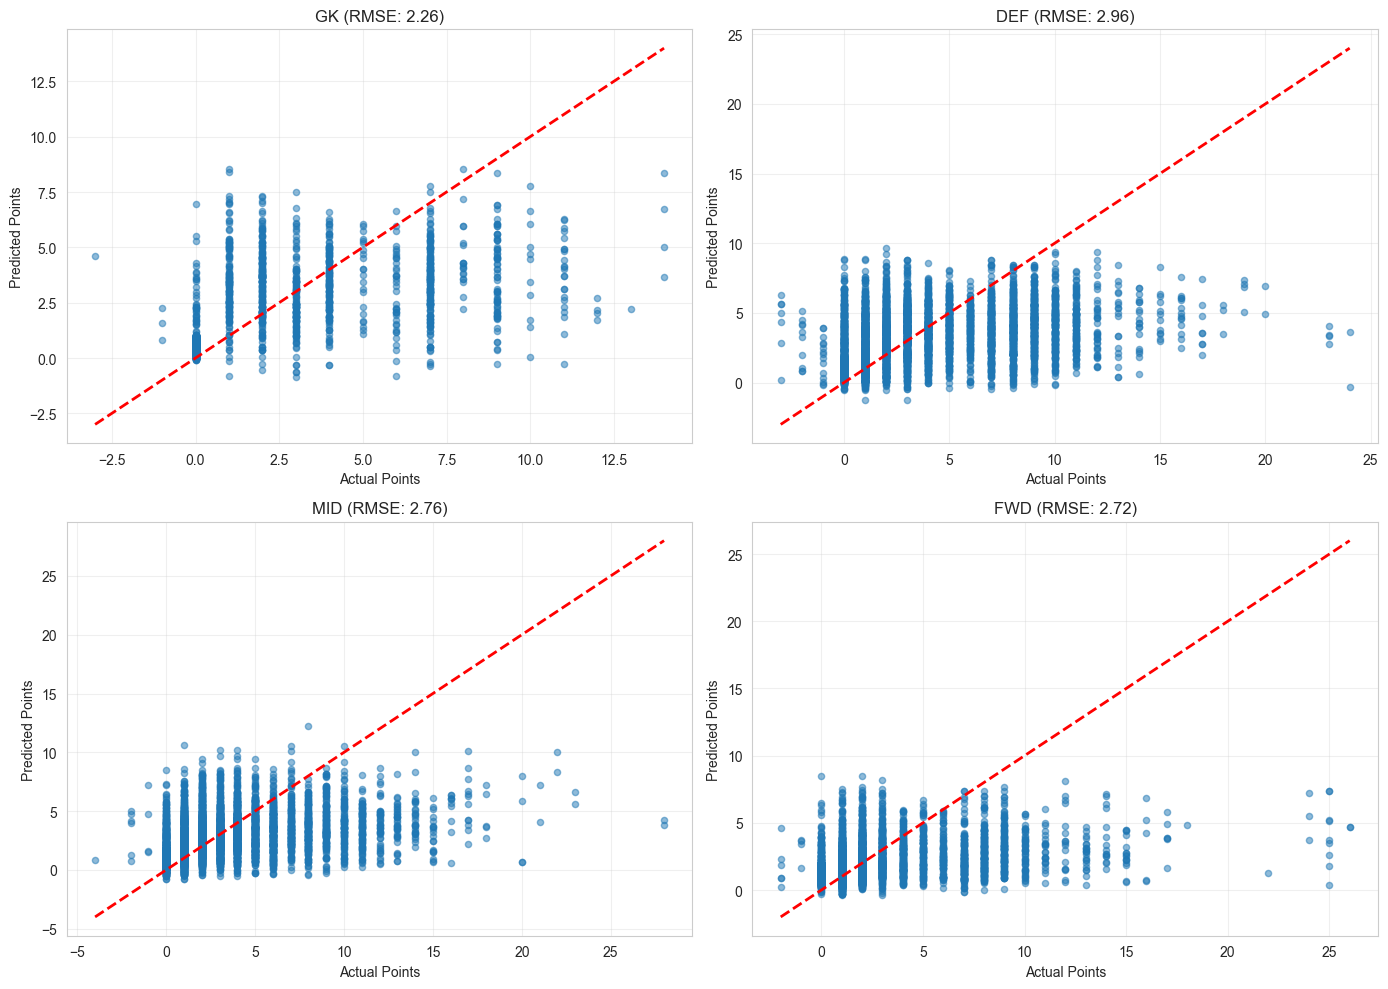

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, position in enumerate(positions):
    # Collect all predictions and actuals for this position across walk-forward folds
    position_preds = []
    position_acts = []
    
    for test_gw in test_gws:
        train_data = df_train[(df_train['gameweek'] < test_gw) & (df_train['position'] == position)]
        test_data = df_train[(df_train['gameweek'] == test_gw) & (df_train['position'] == position)]
        
        if len(train_data) == 0 or len(test_data) == 0:
            continue
        
        X_train = train_data[['avg_pts_season', 'avg_pts_last_6', 'fixture_difficulty_encoded', 'is_home_binary']]
        y_train = train_data['points']
        X_test = test_data[['avg_pts_season', 'avg_pts_last_6', 'fixture_difficulty_encoded', 'is_home_binary']]
        y_test = test_data['points']
        
        model = LinearRegression().fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        position_preds.extend(y_pred)
        position_acts.extend(y_test.values)
    
    if len(position_preds) == 0:
        continue
    
    position_preds = np.array(position_preds)
    position_acts = np.array(position_acts)
    
    ax = axes[idx]
    ax.scatter(position_acts, position_preds, alpha=0.5, s=20)
    ax.plot([position_acts.min(), position_acts.max()], [position_acts.min(), position_acts.max()], 'r--', lw=2)
    ax.set_xlabel('Actual Points')
    ax.set_ylabel('Predicted Points')
    ax.set_title(f'{position} (RMSE: {np.sqrt(mean_squared_error(position_acts, position_preds)):.2f})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Feature Comparison: Improvement from Full vs Baseline

In [ ]:
comparison_rows = []

for position in positions:
    baseline_rmses = [r['rmse'] for r in model_results[position]['baseline']]
    full_rmses = [r['rmse'] for r in model_results[position]['full']]
    
    if len(baseline_rmses) == 0:
        continue
    
    avg_baseline_rmse = np.mean(baseline_rmses)
    avg_full_rmse = np.mean(full_rmses)
    improvement = ((avg_baseline_rmse - avg_full_rmse) / avg_baseline_rmse) * 100
    
    comparison_rows.append({
        'Position': position,
        'Baseline RMSE': avg_baseline_rmse,
        'Full RMSE': avg_full_rmse,
        'Improvement %': improvement
    })

comparison_df = pd.DataFrame(comparison_rows)

print('\n=== IMPROVEMENT: Full Model vs Baseline ===')
print(comparison_df.to_string(index=False))
print(f'\nAverage improvement: {comparison_df["Improvement %"].mean():.2f}%')


=== IMPROVEMENT: Full Model vs Baseline ===
Position  Baseline RMSE  Full RMSE  Improvement %
      GK       2.829570   2.258005      20.199714
     DEF       3.416681   2.933980      14.127777
     MID       3.100237   2.748862      11.333805
     FWD       2.940243   2.723760       7.362760

Average improvement: 13.26%


## 9. Case Study: Lewis Wing Predictions (GW 28-33)

In [ ]:
# Find Lewis Wing
lewis_wing = df_train[df_train['display_name'].str.contains('L. Wing', case=False, na=False)]

if len(lewis_wing) > 0:
    player_id = lewis_wing['player_id'].iloc[0]
    position = lewis_wing['position'].iloc[0]
    
    print(f'Found: {lewis_wing["display_name"].iloc[0]} (ID: {player_id}, Position: {position})')
    
    # Get his data for GW 28-33, deduplicate by taking first row per gameweek
    lewis_full = df_train[(df_train['player_id'] == player_id) & (df_train['gameweek'].isin([28, 29, 30, 31, 32, 33]))]
    lewis_test = lewis_full.drop_duplicates(subset=['gameweek'], keep='first').sort_values('gameweek')
    
    if len(lewis_test) > 0:
        # Train model on his position for GW 1-27
        train_data = df_train[(df_train['gameweek'] < 28) & (df_train['position'] == position)]
        X_train = train_data[['avg_pts_season', 'avg_pts_last_6', 'fixture_difficulty_encoded', 'is_home_binary']]
        y_train = train_data['points']
        
        model = LinearRegression().fit(X_train, y_train)
        
        # Get his features and predictions
        X_lewis = lewis_test[['avg_pts_season', 'avg_pts_last_6', 'fixture_difficulty_encoded', 'is_home_binary']]
        y_lewis_pred = model.predict(X_lewis)
        y_lewis_actual = lewis_test['points'].values
        
        # Build results table
        results = []
        for idx, (_, row) in enumerate(lewis_test[['gameweek', 'opponent_name', 'fixture_difficulty', 'is_home', 'avg_pts_season', 'avg_pts_last_6', 'points']].iterrows()):
            results.append({
                'GW': int(row['gameweek']),
                'Opponent': row['opponent_name'],
                'Fixture': row['fixture_difficulty'],
                'H/A': row['is_home'],
                'Avg Pts (Season)': f"{row['avg_pts_season']:.2f}",
                'Avg Pts (Last 6)': f"{row['avg_pts_last_6']:.2f}",
                'Predicted': f"{y_lewis_pred[idx]:.1f}",
                'Actual': int(row['points'])
            })
        
        results_df = pd.DataFrame(results)
        
        print(f'\n=== Lewis Wing: Predictions GW 28-33 (deduplicated) ===')
        print(results_df.to_string(index=False))
        
        # Summary metrics
        mae = mean_absolute_error(y_lewis_actual, y_lewis_pred)
        rmse = np.sqrt(mean_squared_error(y_lewis_actual, y_lewis_pred))
        
        print(f'\nMAE:  {mae:.2f}')
        print(f'RMSE: {rmse:.2f}')
        print(f'Total predicted: {y_lewis_pred.sum():.0f}')
        print(f'Total actual:    {y_lewis_actual.sum()}')
    else:
        print('No data for GW 28-33')
else:
    print('Lewis Wing not found in data')

Found: L. Wing (ID: 432647, Position: MID)

=== Lewis Wing: Predictions GW 28-33 (deduplicated) ===
 GW  Opponent Fixture H/A Avg Pts (Season) Avg Pts (Last 6) Predicted  Actual
 28   AFC Wim  medium   A             2.36             6.50       5.6       2
 29    Bolton    hard   H             2.36             6.33       5.5      10
 30 Port Vale    easy   A             2.36             8.50       7.6      10
 31  Bradford    hard   H             2.36             8.83       7.8       7
 32     Luton  medium   A             2.36             8.17       7.2      10
 33    Burton    easy   A             2.36             9.17       8.3       9

MAE:  2.48
RMSE: 2.84
Total predicted: 42
Total actual:    48


In [ ]:
# Find Lewis Wing
lewis_wing = df_train[df_train['display_name'].str.contains('S. Bradley', case=False, na=False)]

if len(lewis_wing) > 0:
    player_id = lewis_wing['player_id'].iloc[0]
    position = lewis_wing['position'].iloc[0]
    
    print(f'Found: {lewis_wing["display_name"].iloc[0]} (ID: {player_id}, Position: {position})')
    
    # Get his data for GW 28-33, deduplicate by taking first row per gameweek
    lewis_full = df_train[(df_train['player_id'] == player_id) & (df_train['gameweek'].isin([28, 29, 30, 31, 32, 33]))]
    lewis_test = lewis_full.drop_duplicates(subset=['gameweek'], keep='first').sort_values('gameweek')
    
    if len(lewis_test) > 0:
        # Train model on his position for GW 1-27
        train_data = df_train[(df_train['gameweek'] < 28) & (df_train['position'] == position)]
        X_train = train_data[['avg_pts_season', 'avg_pts_last_6', 'fixture_difficulty_encoded', 'is_home_binary']]
        y_train = train_data['points']
        
        model = LinearRegression().fit(X_train, y_train)
        
        # Get his features and predictions
        X_lewis = lewis_test[['avg_pts_season', 'avg_pts_last_6', 'fixture_difficulty_encoded', 'is_home_binary']]
        y_lewis_pred = model.predict(X_lewis)
        y_lewis_actual = lewis_test['points'].values
        
        # Build results table
        results = []
        for idx, (_, row) in enumerate(lewis_test[['gameweek', 'opponent_name', 'fixture_difficulty', 'is_home', 'avg_pts_season', 'avg_pts_last_6', 'points']].iterrows()):
            results.append({
                'GW': int(row['gameweek']),
                'Opponent': row['opponent_name'],
                'Fixture': row['fixture_difficulty'],
                'H/A': row['is_home'],
                'Avg Pts (Season)': f"{row['avg_pts_season']:.2f}",
                'Avg Pts (Last 6)': f"{row['avg_pts_last_6']:.2f}",
                'Predicted': f"{y_lewis_pred[idx]:.1f}",
                'Actual': int(row['points'])
            })
        
        results_df = pd.DataFrame(results)
        
        print(f'\n=== Lewis Wing: Predictions GW 28-33 (deduplicated) ===')
        print(results_df.to_string(index=False))
        
        # Summary metrics
        mae = mean_absolute_error(y_lewis_actual, y_lewis_pred)
        rmse = np.sqrt(mean_squared_error(y_lewis_actual, y_lewis_pred))
        
        print(f'\nMAE:  {mae:.2f}')
        print(f'RMSE: {rmse:.2f}')
        print(f'Total predicted: {y_lewis_pred.sum():.0f}')
        print(f'Total actual:    {y_lewis_actual.sum()}')
    else:
        print('No data for GW 28-33')
else:
    print('Lewis Wing not found in data')

Found: S. Bradley (ID: 90495, Position: DEF)

=== Lewis Wing: Predictions GW 28-33 (deduplicated) ===
 GW     Opponent Fixture H/A Avg Pts (Season) Avg Pts (Last 6) Predicted  Actual
 28     Plymouth    hard   A             1.90             5.83       4.6       3
 29  Northampton    easy   H             1.90             5.17       4.5       3
 30    Mansfield  medium   A             1.91             6.00       5.0       9
 31    Blackpool    easy   H             1.91             6.67       6.0       9
 32      Cardiff    hard   A             1.91             6.83       5.6       9
 33 Huddersfield  medium   A             1.91             7.67       6.7       9

MAE:  2.62
RMSE: 2.77
Total predicted: 32
Total actual:    42
